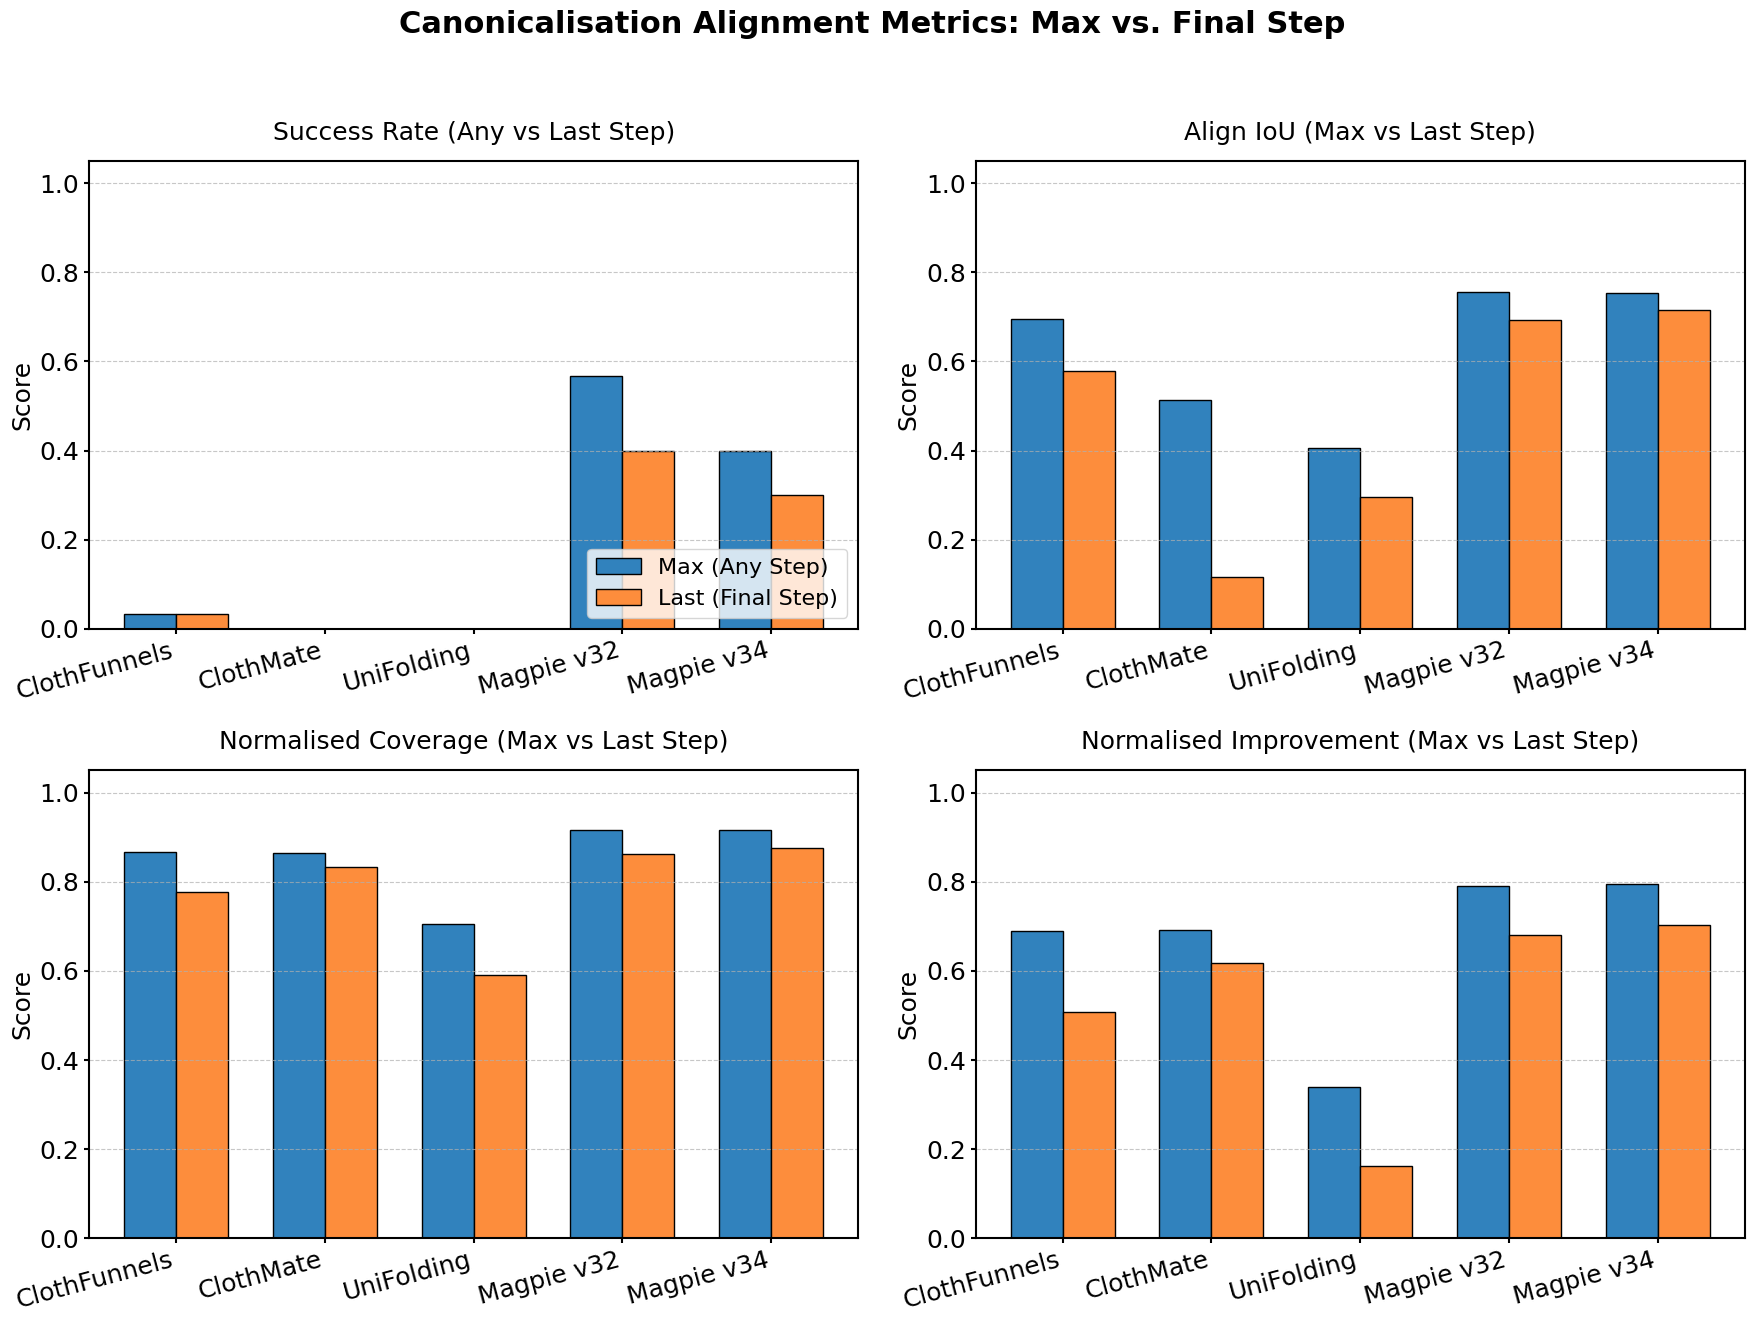

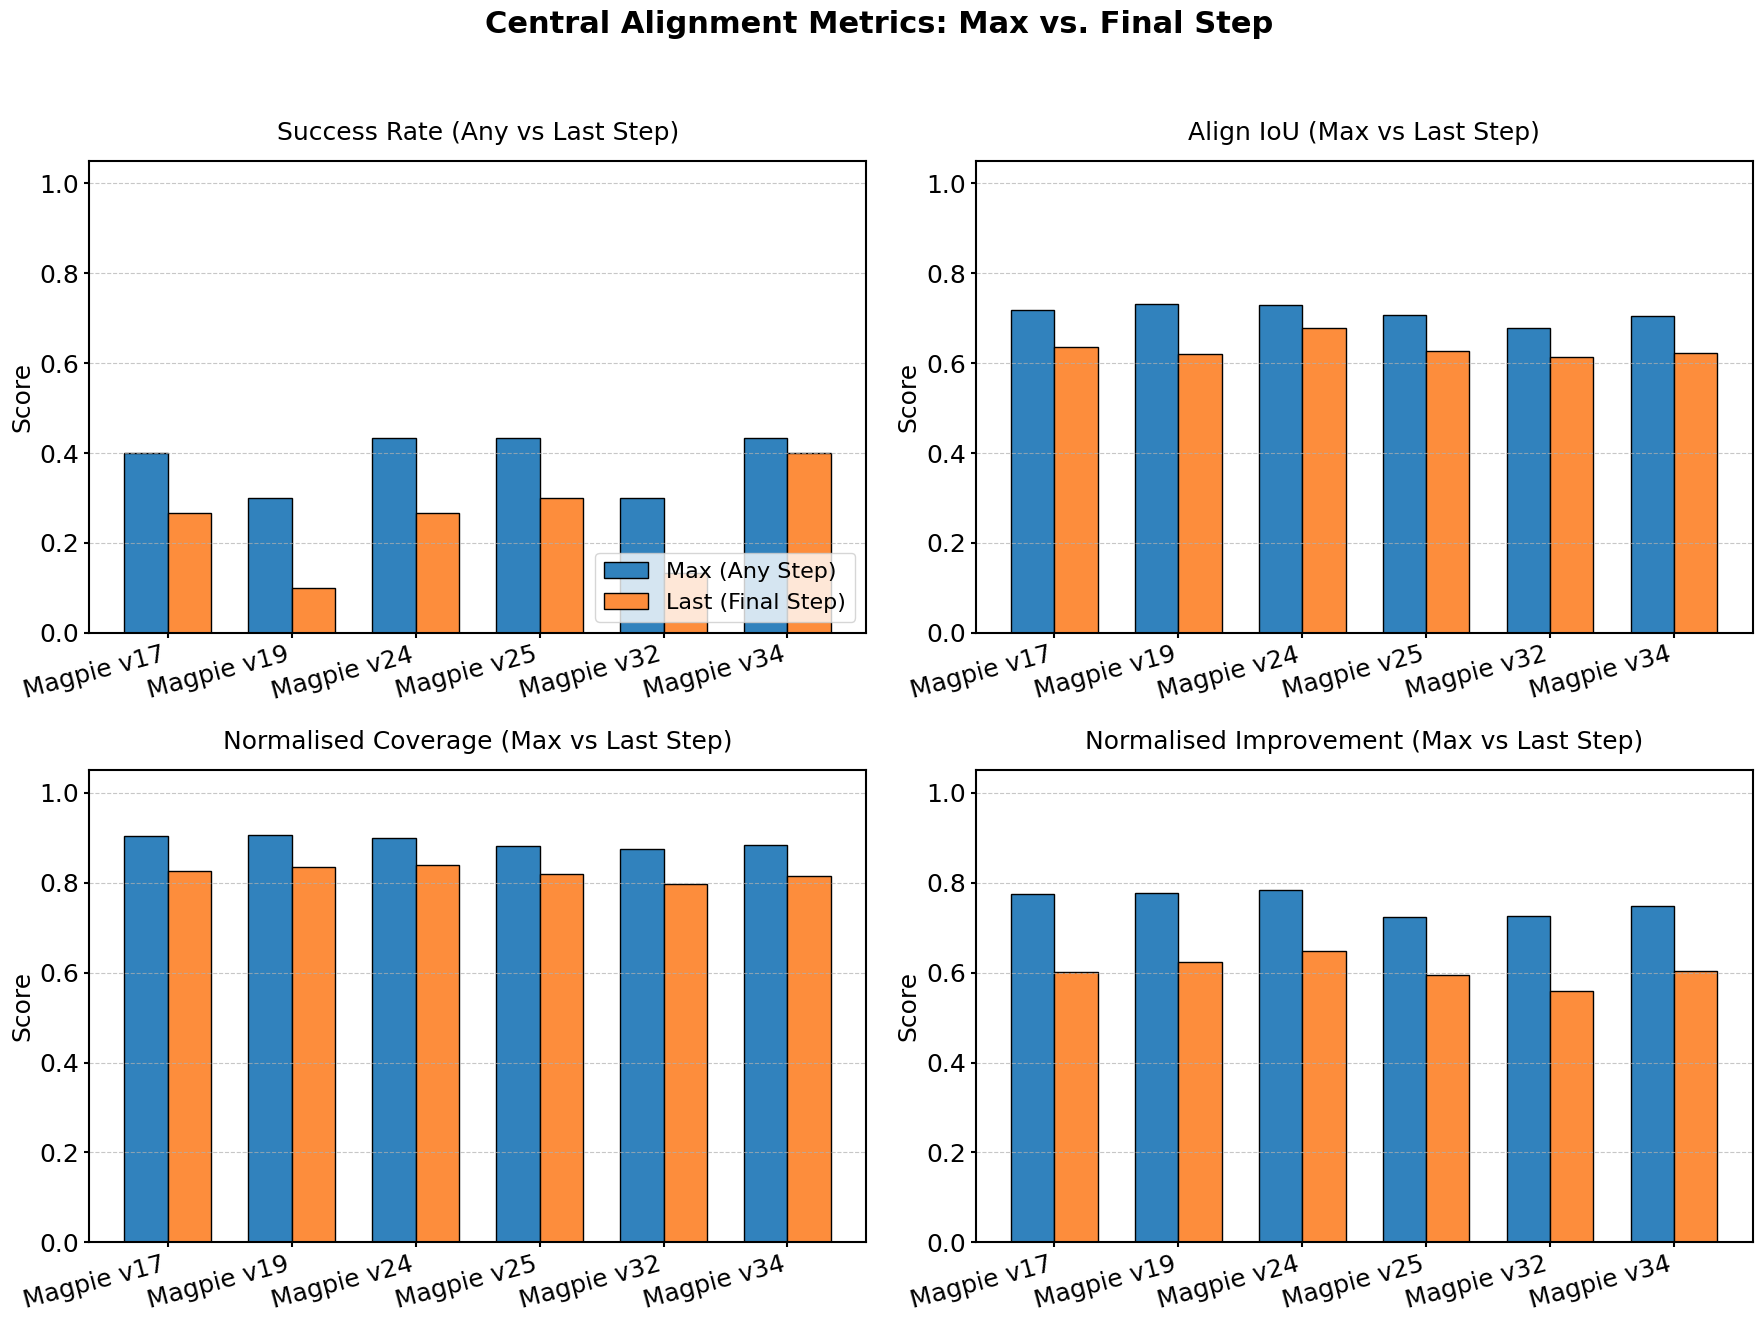

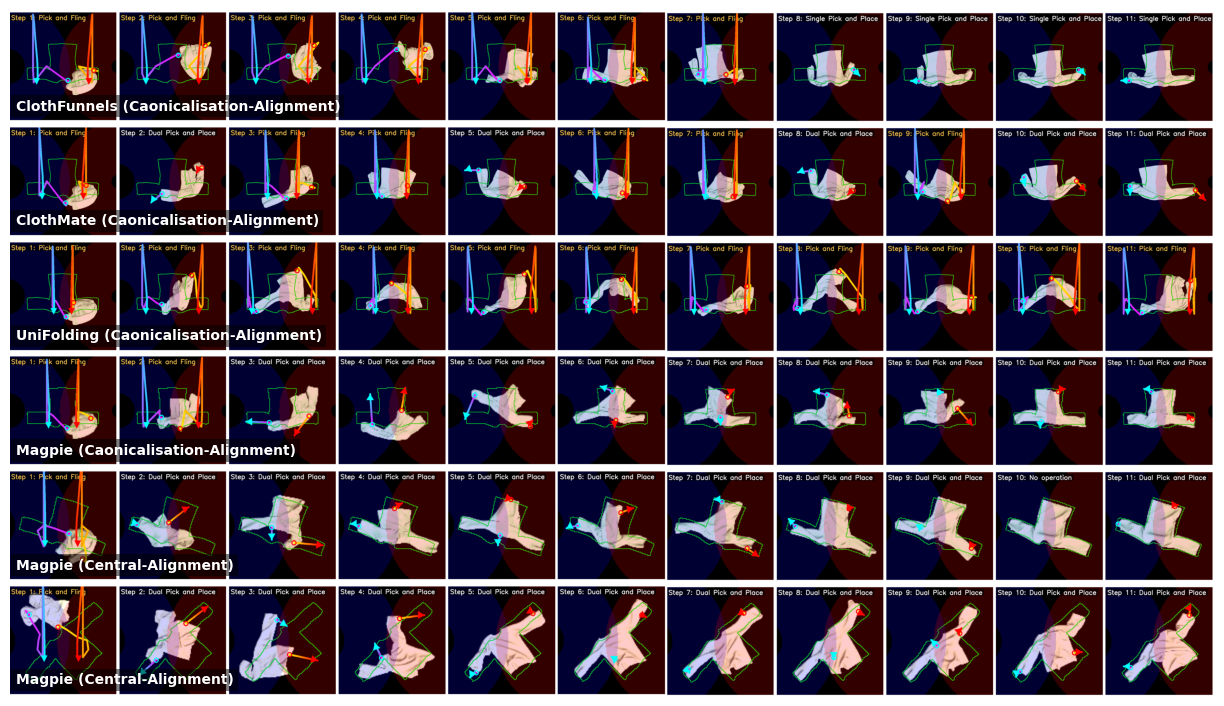

In [ ]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from matplotlib.lines import Line2D

# --- 1. Publication-Ready Style Settings ---
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'font.family': 'sans-serif',
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

COLORS = {
    'ClothFunnels': '#1f77b4',
    'ClothMate': '#2ca02c',
    'UniFolding': '#9467bd',
    'Magpie': '#d62728',
    'Max_Metric': '#3182bd',
    'Last_Metric': '#fd8d3c'
}

# --- 2. Helper Functions ---
def parse_list(val):
    parsed_list = []
    if pd.isna(val): return []
    if isinstance(val, list): parsed_list = val
    elif isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            parsed_list = parsed if isinstance(parsed, list) else [parsed]
        except (ValueError, SyntaxError):
            try: parsed_list = [float(val)]
            except ValueError: parsed_list = []
    elif isinstance(val, (int, float)):
        parsed_list = [val]
        
    clipped_list = []
    for x in parsed_list:
        try: clipped_list.append(max(0.0, min(1.0, float(x))))
        except (ValueError, TypeError): pass 
    return clipped_list

def aggregate_performance_custom(csv_path, iou_thresh=0.8, nc_thresh=0.9, max_steps=20):
    df = pd.read_csv(csv_path)
    df["algn_iou"] = df["evaluation/algn_IoU_to_flattened"].apply(parse_list)
    df["nc"] = df["evaluation/normalised_coverage"].apply(parse_list)
    df["ni"] = df["evaluation/normalised_improvement"].apply(parse_list)
    
    any_step_success, last_step_success = [], []
    for iou_list, nc_list in zip(df["algn_iou"], df["nc"]):
        iou_sliced = iou_list[:max_steps] if max_steps is not None else iou_list
        nc_sliced = nc_list[:max_steps] if max_steps is not None else nc_list
        
        if any((i > iou_thresh and n > nc_thresh) for i, n in zip(iou_sliced, nc_sliced)):
            any_step_success.append(1)
        else: any_step_success.append(0)
            
        if len(iou_sliced) > 0 and len(nc_sliced) > 0:
            if iou_sliced[-1] > iou_thresh and nc_sliced[-1] > nc_thresh:
                last_step_success.append(1)
            else: last_step_success.append(0)
        else: last_step_success.append(0)

    def safe_max(lst):
        sliced = lst[:max_steps] if max_steps is not None else lst
        return np.max(sliced) if len(sliced) > 0 else 0.0
        
    def safe_last(lst):
        sliced = lst[:max_steps] if max_steps is not None else lst
        return sliced[-1] if len(sliced) > 0 else 0.0

    return {
        "SR_max_mean": np.mean(any_step_success),
        "IoU_max_mean": np.mean([safe_max(x) for x in df["algn_iou"]]),
        "NC_max_mean": np.mean([safe_max(x) for x in df["nc"]]),
        "NI_max_mean": np.mean([safe_max(x) for x in df["ni"]]),
        "SR_last_mean": np.mean(last_step_success),
        "IoU_last_mean": np.mean([safe_last(x) for x in df["algn_iou"]]),
        "NC_last_mean": np.mean([safe_last(x) for x in df["nc"]]),
        "NI_last_mean": np.mean([safe_last(x) for x in df["ni"]]),
    }

# --- 3. Processing and Plotting Functions ---
def process_and_plot_task(data_dir, experiments, task_title):
    rows = []
    for exp in experiments:
        path = os.path.join(data_dir, exp["name"], exp["check"], "performance.csv")
        if os.path.exists(path):
            m = aggregate_performance_custom(path, iou_thresh=0.8, nc_thresh=0.9)
            m["experiment"] = exp["label"]
            rows.append(m)
        else:
            print(f"[{task_title}] File not found, skipping: {path}")

    if not rows:
        print(f"[{task_title}] Warning: No files found. Using dummy data for testing.")
        for exp in experiments:
            rows.append({
                "experiment": exp["label"],
                "SR_max_mean": np.random.uniform(0.6, 0.9), "SR_last_mean": np.random.uniform(0.4, 0.7),
                "IoU_max_mean": np.random.uniform(0.7, 0.95), "IoU_last_mean": np.random.uniform(0.5, 0.8),
                "NC_max_mean": np.random.uniform(0.8, 0.98), "NC_last_mean": np.random.uniform(0.6, 0.9),
                "NI_max_mean": np.random.uniform(0.5, 0.8), "NI_last_mean": np.random.uniform(0.3, 0.6)
            })

    results_df = pd.DataFrame(rows)

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle(f'{task_title} Metrics: Max vs. Final Step', fontsize=22, fontweight='bold', y=0.95)

    metrics_to_plot = [
        ('SR_max_mean', 'SR_last_mean', 'Success Rate (Any vs Last Step)'),
        ('IoU_max_mean', 'IoU_last_mean', 'Align IoU (Max vs Last Step)'),
        ('NC_max_mean', 'NC_last_mean', 'Normalised Coverage (Max vs Last Step)'),
        ('NI_max_mean', 'NI_last_mean', 'Normalised Improvement (Max vs Last Step)')
    ]

    x = np.arange(len(results_df['experiment']))
    width = 0.35

    for i, ax in enumerate(axes.flatten()):
        max_col, last_col, title = metrics_to_plot[i]
        
        ax.bar(x - width/2, results_df[max_col], width, label='Max (Any Step)', color=COLORS['Max_Metric'], edgecolor='black')
        ax.bar(x + width/2, results_df[last_col], width, label='Last (Final Step)', color=COLORS['Last_Metric'], edgecolor='black')
        
        ax.set_title(title, pad=15)
        ax.set_ylabel('Score')
        ax.set_xticks(x)
        ax.set_xticklabels(results_df['experiment'], rotation=15, ha='right')
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        if i == 0: ax.legend(loc='lower right')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

def plot_trajectory_visualizations(data_dir, experiments, episodes_list=None, num_steps=11, crop_params=None):
    if episodes_list is None:
        episodes_list = [0] * len(experiments)
        
    # Default fallback settings
    if crop_params is None:
        crop_params = {
            'start_x': 0.02, 'stride_x': 0.16, 'box_w': 0.15,
            'start_y': 0.02, 'stride_y': 0.245, 'box_h': 0.23,
            'row_y_offsets': [0.0, 0.0, 0.0, 0.0],
            'pad_width_frac': 0.005
        }

    num_exps = len(experiments)
    if num_exps == 0: return
        
    fig, axes = plt.subplots(nrows=num_exps, ncols=1, figsize=(20, num_exps * 1.3))
    if num_exps == 1: axes = [axes]

    for row_idx, exp in enumerate(experiments):
        exp_label = exp["label"]
        ax = axes[row_idx]
        ep_idx = episodes_list[row_idx] if row_idx < len(episodes_list) else 0
        
        vis_dir = os.path.join(data_dir, exp["name"], exp["check"], "performance_visualisation")
        img_path = os.path.join(vis_dir, f"episode_{ep_idx}_trajectory.png")
        
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            h, w = img.shape[:2]
            
            grid_cols = 6
            row_offsets = crop_params.get('row_y_offsets', [0.0]*4)
            pad_w = int(w * crop_params.get('pad_width_frac', 0.005))
            
            # Ensure every box is EXACTLY the same size in pixels
            bw = int(w * crop_params['box_w'])
            bh = int(h * crop_params['box_h'])
            
            step_images = []
            
            for i in range(num_steps):
                r = i // grid_cols  
                c = i % grid_cols   
                
                # Sliding Window logic
                y_shift = int(h * (row_offsets[r] if r < len(row_offsets) else 0.0))
                
                x1 = int(w * (crop_params['start_x'] + c * crop_params['stride_x']))
                y1 = int(h * (crop_params['start_y'] + r * crop_params['stride_y'])) + y_shift
                
                cell = img[y1:y1+bh, x1:x1+bw]
                step_images.append(cell)
                
                # Manually inject perfectly uniform white padding between steps
                if i < num_steps - 1 and pad_w > 0:
                    pad_shape = (bh, pad_w) if img.ndim == 2 else (bh, pad_w, img.shape[2])
                    pad_val = 1.0 if np.issubdtype(img.dtype, np.floating) else 255
                    padding = np.full(pad_shape, pad_val, dtype=img.dtype)
                    step_images.append(padding)
            
            # Flatten to a single row
            flat_row_img = np.concatenate(step_images, axis=1)
            ax.imshow(flat_row_img)
            
            # Top row ONLY: Add step numbers tracking the dynamic new widths
            # if row_idx == 0:
            #     current_x = 0
            #     for s in range(num_steps):
            #         x_center = current_x + (bw / 2)
            #         y_pos = - (bh * 0.05) 
            #         ax.text(x_center, y_pos, f"Step {s}", ha='center', va='bottom', fontsize=12, fontweight='bold')
            #         current_x += bw + pad_w # Advance by box width + padding width
            
            # Agent name bottom-left corner
            ax.text(bw * 0.05, bh * 0.92, exp_label, 
                    color='white', fontsize=10, fontweight='bold', ha='left', va='bottom',
                    bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=3))

        else:
            ax.text(0.5, 0.5, f'Image not found:\n{img_path.split("/")[-1]}', ha='center', va='center', fontsize=12, color='gray')
            ax.set_xlim(0, 1)
            ax.set_ylim(1, 0)
        
        ax.axis('off')

    plt.subplots_adjust(hspace=0.02, top=0.90, bottom=0.02, left=0.02, right=0.98)
    
    plt.savefig('traj_vis_cmp.png', bbox_inches='tight', pad_inches=0.1, dpi=400)

# --- 4. Main Execution ---
data_dir = "/media/hcv530/T7/garment_folding_data"

canon_experiments = [
    {"name": "cloth_funnel_longsleeve_canon_align_from_crumpled", "label": "ClothFunnels", "check": "eval_checkpoint_-1"},
    {"name": "clothmate_longsleeve_canon_align_from_crumpled", "label": "ClothMate", "check": "eval_checkpoint_True"},
    {"name": "unifolding_canon_align_from_crumpled", "label": "UniFolding", "check": "eval_checkpoint_True"},
    {"name": "transfer_eval_magpie_ctr_align_longsleeve_p4_v32/magpie/multi_longsleeve_provide_semkey_pixel_no_success_stop_resol_128_workspace", "label": "Magpie v32", "check": "eval_checkpoint_-2"},
    {"name": "transfer_eval_magpie_ctr_align_longsleeve_p4_v34/magpie/multi_longsleeve_provide_semkey_pixel_no_success_stop_resol_128_workspace", "label": "Magpie v34", "check": "eval_checkpoint_-2"},
]

central_experiments = [
    {"name": "magpie_ctr_align_longsleeve_p4_v17", "label": "Magpie v17", "check": "eval_checkpoint_100000"},
    {"name": "magpie_ctr_align_longsleeve_p4_v19", "label": "Magpie v19", "check": "eval_checkpoint_100000"},
    {"name": "magpie_ctr_align_longsleeve_p4_v24", "label": "Magpie v24", "check": "eval_checkpoint_100000"},
    {"name": "magpie_ctr_align_longsleeve_p4_v25", "label": "Magpie v25", "check": "eval_checkpoint_100000"},
    {"name": "magpie_ctr_align_longsleeve_p4_v32", "label": "Magpie v32", "check": "eval_checkpoint_-2"},
    {"name": "magpie_ctr_align_longsleeve_p4_v34", "label": "Magpie v34", "check": "eval_checkpoint_-2"},
]

plot_experiments = [
    {"name": "cloth_funnel_longsleeve_canon_align_from_crumpled", "label": "ClothFunnels (Caonicalisation-Alignment)", "check": "eval_checkpoint_-1"},
    {"name": "clothmate_longsleeve_canon_align_from_crumpled", "label": "ClothMate (Caonicalisation-Alignment)", "check": "eval_checkpoint_True"},
    {"name": "unifolding_canon_align_from_crumpled", "label": "UniFolding (Caonicalisation-Alignment)", "check": "eval_checkpoint_True"},
    {"name": "transfer_eval_magpie_ctr_align_longsleeve_p4_v46/magpie/multi_longsleeve_provide_semkey_pixel_no_success_stop_resol_128_workspace_height_2", "label": "Magpie (Caonicalisation-Alignment)", "check": "eval_checkpoint_-2"},
    #{"name": "transfer_eval_magpie_ctr_align_longsleeve_p4_v46/magpie/multi_longsleeve_provide_semkey_pixel_no_success_stop_resol_128_workspace_height_2", "label": "Magpie (Caonicalisation-Alignment)", "check": "eval_checkpoint_-2"},
    {"name": "magpie_ctr_align_longsleeve_p4_v46", "label": "Magpie (Central-Alignment)", "check": "eval_checkpoint_-2"},
    {"name": "magpie_ctr_align_longsleeve_p4_v46", "label": "Magpie (Central-Alignment)", "check": "eval_checkpoint_-2"},
]

plot_episodes_to_show = [
    0, # ClothFunnels
    0, # ClothMate
    0, # UniFolding
    0, # Magpie (first instance)
    # 11, # Magpie (second instance)
    0, # Magpie (third instance)
    8  # Magpie (fourth instance)
]

# --- THE NEW SLIDING WINDOW CONFIGURATION ---
my_crop_settings = {
    'start_x': 0.01,        # X-position of the first image 
    'stride_x': 0.165,      # The jump distance between columns 
    'box_w': 0.160,         # The exact width of the extracted square

    'start_y': 0.0,         # Y-position of the first row 
    'stride_y': 0.25,       # The jump distance between rows 
    'box_h': 0.247,         # The exact height of the extracted square

    # [Row 0, Row 1, Row 2, Row 3]
    # Set to all zeros to see if they naturally align. 
    # If row 1 (Steps 6-11) still looks lower, change the second number to 0.01 or 0.02.
    'row_y_offsets': [0.005, 0.0, 0.0, 0.0],

    # Uniform white border between all images
    'pad_width_frac': 0.0 
}

# 1. Bar Charts
process_and_plot_task(data_dir, canon_experiments, task_title="Canonicalisation Alignment")
process_and_plot_task(data_dir, central_experiments, task_title="Central Alignment")

# 2. Visualizations
plot_trajectory_visualizations(
    data_dir, 
    plot_experiments, 
    episodes_list=plot_episodes_to_show, 
    num_steps=11, 
    crop_params=my_crop_settings
)